<a href="https://colab.research.google.com/github/ngophuctaivp20-crypto/Final-Project-/blob/main/Developer_Diary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1:

My finance assistanct project that I'm trying to do is the Saving Goal Coach.  I learned how my project uses variables and conditionals. Variables store things like the currency (AUD) and the Gemini model name. Conditionals (if/elif/else) decide things, like whether a goal is "On track" or "Behind".

The prompt that I asked the Gemini is that"I am developing a Finance Assistant project for my university unit, focusing on a Savings Goal Coach. Could you demonstrate how variables and conditional statements can be used to calculate a user's monthly savings requirement and determine whether their goal is achievable?"

What it returned is that Gemini produced three code cells below demonstrating the requested concepts. The first defined variables representing the user's savings goal: a target amount of $5,000, current savings of 1,500, and a target date of 31 December 2025, alongside the current date obtained through the datetime module. The second calculated the remaining amount required (3,500) and the number of months remaining, using an if/else statement to prevent division by zero where the deadline had already passed. The third applied an if/elif/else structure to compare the required monthly contribution against the user's estimated savings capacity of 250 per month, returning one of four outcomes: goal achieved, deadline passed, on track, or behind schedule.

Base on the code it provided below,I kept the structure because it is clear for the user when they know whetger the progress has passed or not.

On the other hand, I saw that the target date is 31/12/2025, therefore, it will not show whether the progress is the "on track" or "behind" branches. The fix is to change it to a future date such as 2027-11-30. Also, the code only compare how much saving per month and they ignores days but I decide to kept it because I want to make a demo of how my project will run in the future

### Demonstrating Savings Goal Coach Logic

Let's set up some variables to simulate a user's savings goal and then use conditional logic to assess their progress.

In [ ]:
import datetime

# 1. Define Variables
# User's savings goal parameters
target_amount = 5000  # The total amount the user wants to save
current_savings = 1500 # The amount the user has saved so far
target_date = datetime.date(2026,9,30) # The date by which the user wants to achieve their goal

# Current date (for calculation)
current_date = datetime.date.today()

print(f"Target Amount: ${target_amount:.2f}")
print(f"Current Savings: ${current_savings:.2f}")
print(f"Target Date: {target_date}")
print(f"Current Date: {current_date}")

Target Amount: $5000.00
Current Savings: $1500.00
Target Date: 2026-09-30
Current Date: 2026-09-28


In [ ]:
# 2. Calculate Monthly Savings Requirement

# Calculate remaining amount to save
amount_needed = target_amount - current_savings

# Calculate remaining months
# This is a simplified calculation, a real app might consider days, weeks, etc.
months_remaining = (target_date.year - current_date.year) * 12 + (target_date.month - current_date.month)

# Ensure months_remaining is not zero or negative to avoid division by zero or nonsensical results
if months_remaining <= 0:
    monthly_savings_required = amount_needed # Or handle as already past due
    print("Target date is in the past or current month.")
else:
    monthly_savings_required = amount_needed / months_remaining

print(f"\nAmount Needed: ${amount_needed:.2f}")
print(f"Months Remaining: {months_remaining}")
print(f"Monthly Savings Required: ${monthly_savings_required:.2f}")

Target date is in the past or current month.

Amount Needed: $3500.00
Months Remaining: 0
Monthly Savings Required: $3500.00


In [ ]:
# 3. Determine if the Goal is Achievable/On Track (Conditional Statements)

# Let's assume the user can realistically save $250 per month
user_can_save_per_month = 250

print(f"\nUser's Estimated Monthly Savings Capacity: ${user_can_save_per_month:.2f}")

if amount_needed <= 0:
    print("Congratulations! You have already reached your savings goal.")
elif months_remaining <= 0:
    print("The target date has passed. You need to save the full remaining amount immediately or adjust your goal.")
elif user_can_save_per_month >= monthly_savings_required:
    print("Status: On track! You can achieve your goal by saving enough each month.")
    print(f"You need to save ${monthly_savings_required:.2f} per month.")
else:
    print("Status: Behind schedule. You need to increase your monthly savings or extend your target date.")
    print(f"You need to save ${monthly_savings_required:.2f} per month, but you are currently saving ${user_can_save_per_month:.2f}.")


User's Estimated Monthly Savings Capacity: $250.00
The target date has passed. You need to save the full remaining amount immediately or adjust your goal.


#2
 In this diary, I want to get in touch with the loops and functions to develope my Saving Goal Coach. I want to try calculate the monthly savings required for several goals stored in a list, and to total a user's spending by category from a list of transactions.

Therefore, the prompt I asked to Gemini is that "I am developing a Savings Goal Coach for my university Finance Assistant project.
Could you demonstrate how functions and loops can be used to: Calculate the monthly savings required for several savings goals stored in a list, where each goal has a name, target amount, current savings and deadline.And Total a user's spending by category from a list of transactions, where each transaction has a date, description, category and amount.Please explain how each function and loop works."

From the code below, what I will kept is keeping the list of saving goals and loop and calculate saving each goals. I want to keep it because placing the calculation in a function means the logic is written once and reused for every goal, which avoids repeating code and makes it easier to fix if something is wrong. What I would like to changed is that I would added the sort spending categories from highest to lowest in "Total Spending Category" section because I want to make the user understand which things they are spend the most so that it makes them easier to manage after that.

When I asked Gemini, it showed me exactly what I want to know and there are nothing that I rejected.

## Demonstrating Functions and Loops for Savings Goal Coach

### Task 1: Calculate Monthly Savings for Multiple Goals

In [ ]:
import datetime

# Define a list of savings goals
savings_goals = [
    {
        "name": "New Car Down Payment",
        "target_amount": 10000,
        "current_savings": 2000,
        "target_date": datetime.date(2027, 12, 31)
    },
    {
        "name": "Vacation Fund",
        "target_amount": 3000,
        "current_savings": 500,
        "target_date": datetime.date(2027, 6, 30)
    },
    {
        "name": "Emergency Fund",
        "target_amount": 5000,
        "current_savings": 4500,
        "target_date": datetime.date(2027, 3, 31)
    }
]

def calculate_monthly_savings_required(goal):
    """
    Calculates the monthly savings required for a single savings goal.
    """
    current_date = datetime.date.today()
    amount_needed = goal["target_amount"] - goal["current_savings"]
    target_date = goal["target_date"]

    months_remaining = (target_date.year - current_date.year) * 12 + \
                       (target_date.month - current_date.month)

    if months_remaining <= 0:
        return amount_needed  # If target date is past or current month, need to save all now
    else:
        return amount_needed / months_remaining

# Loop through each goal and calculate monthly savings
print("Monthly Savings Requirements for Each Goal:")
for goal in savings_goals:
    monthly_req = calculate_monthly_savings_required(goal)
    print(f"- {goal['name']}: ${monthly_req:.2f} per month")

Monthly Savings Requirements for Each Goal:
- New Car Down Payment: $533.33 per month
- Vacation Fund: $277.78 per month
- Emergency Fund: $83.33 per month


#### Explanation for Task 1:

*   **`savings_goals` List**: This list holds dictionaries, where each dictionary represents a distinct savings goal with its `name`, `target_amount`, `current_savings`, and `target_date`.
*   **`calculate_monthly_savings_required(goal)` Function**: This function takes a single `goal` dictionary as input. It calculates the `amount_needed` and the `months_remaining` until the `target_date`. It then divides the `amount_needed` by `months_remaining` to get the monthly requirement. A conditional check handles cases where the target date has passed or is in the current month, returning the full `amount_needed`.
*   **`for` Loop**: The `for` loop iterates through each `goal` in the `savings_goals` list. In each iteration, it calls the `calculate_monthly_savings_required` function for the current `goal` and prints the result, providing a breakdown of savings needed for each objective.

### Task 2: Total Spending by Category

In [ ]:
# Define a list of user transactions
transactions = [
    {"date": "2024-09-01", "description": "Groceries", "category": "Food", "amount": 75.50},
    {"date": "2024-09-02", "description": "Movie Tickets", "category": "Entertainment", "amount": 30.00},
    {"date": "2024-09-03", "description": "Dinner out", "category": "Food", "amount": 60.25},
    {"date": "2024-09-04", "description": "Bus Fare", "category": "Transport", "amount": 5.00},
    {"date": "2024-09-05", "description": "Concert", "category": "Entertainment", "amount": 120.00},
    {"date": "2024-09-06", "description": "Coffee", "category": "Food", "amount": 4.75}
]

def total_spending_by_category(transactions_list):
    """
    Calculates the total spending for each category from a list of transactions.
    """
    category_totals = {}
    for transaction in transactions_list:
        category = transaction["category"]
        amount = transaction["amount"]

        # Add the amount to the respective category total
        # If the category doesn't exist, initialize it to 0 before adding
        category_totals[category] = category_totals.get(category, 0) + amount
    return category_totals

# Calculate and print spending totals
spending_summary = total_spending_by_category(transactions)

print("\nTotal Spending by Category:")
for category, total in spending_summary.items():
    print(f"- {category}: ${total:.2f}")


Total Spending by Category:
- Food: $140.50
- Entertainment: $150.00
- Transport: $5.00


#### Explanation for Task 2:

*   **`transactions` List**: This list contains dictionaries, each representing a financial transaction with its `date`, `description`, `category`, and `amount`.
*   **`total_spending_by_category(transactions_list)` Function**: This function takes the `transactions_list` as input. It initializes an empty dictionary `category_totals`. It then iterates through each `transaction` in the list.
*   **`for` Loop (inside the function)**: For each transaction, it extracts the `category` and `amount`. It then uses `category_totals.get(category, 0) + amount` to either add the amount to an existing category total or initialize the category with the current amount if it's the first transaction for that category.
*   **Output Loop**: After the function returns the `spending_summary` dictionary, another `for` loop iterates through the `items()` (key-value pairs) of this dictionary to print the total spending for each category in a readable format.

#3:

In this diary, I will work on lists and dictionaries,  including nested ones, could be used to organise the data in my Savings Goal Coach. The prompt that I gave to Gemini is that "I am developing a Savings Goal Coach for my university Finance Assistant project.
Could you demonstrate how lists and dictionaries, including nested ones, can be used to store a user's profile? The profile should include the user's name, monthly income, a list of savings goals (each with its own list of past contributions), and a dictionary of monthly budget limits for each spending category.Please show how to access, add to and update this data, and explain how the nested structure works."

 With the result below, what I will kepted is the nested structure because it holds a list of goals,each goal is a dictionary, and each goal has its own list of contributions. What I would change is I would add the updated total contribution to the goals. For example in The Dream Holiday contributions, it add up to 200 + 300 + 400 + 300 = 1,200, which matches current_savings. But after the new 250 contribution, the contributions total 1,450 while current_savings still says 1,200. To fix that, I will updated a new contribution to update the total saving.There are nothing that I rejected because the structure help me to understand well how person's financial information can be organised with their goals, current saving, and contributions with date.

### Task 3: User Profile with Nested Lists and Dictionaries

In [ ]:
import datetime

# 1. Define the User Profile Structure
# A dictionary to hold the user's profile
user_profile = {
    "name": "Alice Wonderland",
    "monthly_income": 4000,
    "savings_goals": [
        {
            "goal_name": "Dream Holiday",
            "target_amount": 5000,
            "current_savings": 1200,
            "target_date": datetime.date(2025, 7, 15),
            "past_contributions": [
                {"date": datetime.date(2024, 1, 1), "amount": 200},
                {"date": datetime.date(2024, 2, 1), "amount": 300},
                {"date": datetime.date(2024, 3, 1), "amount": 400},
                {"date": datetime.date(2024, 4, 1), "amount": 300}
            ]
        },
        {
            "goal_name": "New Laptop",
            "target_amount": 1500,
            "current_savings": 500,
            "target_date": datetime.date(2024, 12, 31),
            "past_contributions": [
                {"date": datetime.date(2024, 3, 1), "amount": 250},
                {"date": datetime.date(2024, 4, 1), "amount": 250}
            ]
        }
    ],
    "monthly_budget_limits": {
        "Food": 600,
        "Transport": 150,
        "Entertainment": 300,
        "Utilities": 200
    }
}

print("Initial User Profile:")
import json
# Custom serializer for datetime.date objects
def date_serializer(obj):
    if isinstance(obj, datetime.date):
        return obj.isoformat()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

print(json.dumps(user_profile, indent=4, default=date_serializer))

Initial User Profile:
{
    "name": "Alice Wonderland",
    "monthly_income": 4000,
    "savings_goals": [
        {
            "goal_name": "Dream Holiday",
            "target_amount": 5000,
            "current_savings": 1200,
            "target_date": "2025-07-15",
            "past_contributions": [
                {
                    "date": "2024-01-01",
                    "amount": 200
                },
                {
                    "date": "2024-02-01",
                    "amount": 300
                },
                {
                    "date": "2024-03-01",
                    "amount": 400
                },
                {
                    "date": "2024-04-01",
                    "amount": 300
                }
            ]
        },
        {
            "goal_name": "New Laptop",
            "target_amount": 1500,
            "current_savings": 500,
            "target_date": "2024-12-31",
            "past_contributions": [
                {
 

#### Explanation: User Profile Structure

*   **`user_profile` Dictionary**: This is the top-level dictionary representing the user's entire profile.
    *   `"name"` and `"monthly_income"` are simple key-value pairs.
    *   `"savings_goals"` is a **list of dictionaries**. Each dictionary within this list represents a single savings goal.
        *   Each goal dictionary contains details like `"goal_name"`, `"target_amount"`, `"current_savings"`, `"target_date"` (a `datetime.date` object).
        *   `"past_contributions"` is a **list of dictionaries** within each savings goal. Each dictionary here represents a specific contribution with its `"date"` and `"amount"`.
    *   `"monthly_budget_limits"` is another **dictionary**. Its keys are spending categories (e.g., "Food", "Transport"), and its values are the corresponding monthly budget limits.

In [ ]:
# 2. Accessing Data

# Accessing basic user information
print(f"\nUser Name: {user_profile['name']}")
print(f"Monthly Income: ${user_profile['monthly_income']:.2f}")

# Accessing a specific savings goal
first_goal = user_profile['savings_goals'][0]
print(f"\nFirst Savings Goal Name: {first_goal['goal_name']}")
print(f"First Goal Target Amount: ${first_goal['target_amount']:.2f}")

# Accessing past contributions for the first goal
print("Past Contributions for First Goal:")
for contribution in first_goal['past_contributions']:
    print(f"  - Date: {contribution['date']}, Amount: ${contribution['amount']:.2f}")

# Accessing a specific budget limit
food_budget = user_profile['monthly_budget_limits']['Food']
print(f"\nFood Budget Limit: ${food_budget:.2f}")


User Name: Alice Wonderland
Monthly Income: $4000.00

First Savings Goal Name: Dream Holiday
First Goal Target Amount: $5000.00
Past Contributions for First Goal:
  - Date: 2024-01-01, Amount: $200.00
  - Date: 2024-02-01, Amount: $300.00
  - Date: 2024-03-01, Amount: $400.00
  - Date: 2024-04-01, Amount: $300.00

Food Budget Limit: $600.00


#### Explanation: Accessing Data

*   **Dictionary Keys**: You access values in a dictionary using their keys (e.g., `user_profile['name']`).
*   **List Indices**: You access items in a list using their numerical index (starting from 0, e.g., `user_profile['savings_goals'][0]` to get the first goal).
*   **Chaining Access**: To access deeply nested data, you chain these operations. For example, `user_profile['savings_goals'][0]['past_contributions'][1]['amount']` would get the amount of the second contribution for the first savings goal.

In [ ]:
# 3. Adding to Data

# Add a new savings goal
new_goal = {
    "goal_name": "New Gadget",
    "target_amount": 800,
    "current_savings": 0,
    "target_date": datetime.date(2024, 10, 31),
    "past_contributions": []
}
user_profile['savings_goals'].append(new_goal)

# Add a new contribution to an existing goal (e.g., 'Dream Holiday')
user_profile['savings_goals'][0]['past_contributions'].append(
    {"date": datetime.date(2024, 5, 1), "amount": 250}
)

# Update current_savings dynamically to match the sum of past contributions
user_profile['savings_goals'][0]['current_savings'] = sum(
    contrib['amount'] for contrib in user_profile['savings_goals'][0]['past_contributions']
)

# Add a new category to monthly budget limits
user_profile['monthly_budget_limits']['Shopping'] = 100

print("\nUser Profile After Adding Data:")
print(json.dumps(user_profile, indent=4, default=date_serializer))


User Profile After Adding Data:
{
    "name": "Alice Wonderland",
    "monthly_income": 4000,
    "savings_goals": [
        {
            "goal_name": "Dream Holiday",
            "target_amount": 5000,
            "current_savings": 1450,
            "target_date": "2025-07-15",
            "past_contributions": [
                {
                    "date": "2024-01-01",
                    "amount": 200
                },
                {
                    "date": "2024-02-01",
                    "amount": 300
                },
                {
                    "date": "2024-03-01",
                    "amount": 400
                },
                {
                    "date": "2024-04-01",
                    "amount": 300
                },
                {
                    "date": "2024-05-01",
                    "amount": 250
                }
            ]
        },
        {
            "goal_name": "New Laptop",
            "target_amount": 1500,
        

#### Explanation: Adding Data

*   **Appending to Lists**: To add new items to a list (like a new savings goal or a new contribution), use the `.append()` method.
*   **Updating Total Savings**: After appending a new contribution, we update `current_savings` by summing the amounts of all contributions in `past_contributions`. This ensures that the progress remains accurate and synchronized.
*   **Adding Dictionary Entries**: To add a new key-value pair to a dictionary (like a new budget category), simply assign a value to a new key (e.g., `dictionary['new_key'] = value`).

In [ ]:
# 4. Updating Data

# Update user's monthly income
user_profile['monthly_income'] = 4500

# Update current savings for the 'New Laptop' goal
# First, find the 'New Laptop' goal
for goal in user_profile['savings_goals']:
    if goal['goal_name'] == 'New Laptop':
        goal['current_savings'] = 750 # Update the value
        break

# Update a budget limit
user_profile['monthly_budget_limits']['Entertainment'] = 350

print("\nUser Profile After Updating Data:")
print(json.dumps(user_profile, indent=4, default=date_serializer))


User Profile After Updating Data:
{
    "name": "Alice Wonderland",
    "monthly_income": 4500,
    "savings_goals": [
        {
            "goal_name": "Dream Holiday",
            "target_amount": 5000,
            "current_savings": 1450,
            "target_date": "2025-07-15",
            "past_contributions": [
                {
                    "date": "2024-01-01",
                    "amount": 200
                },
                {
                    "date": "2024-02-01",
                    "amount": 300
                },
                {
                    "date": "2024-03-01",
                    "amount": 400
                },
                {
                    "date": "2024-04-01",
                    "amount": 300
                },
                {
                    "date": "2024-05-01",
                    "amount": 250
                }
            ]
        },
        {
            "goal_name": "New Laptop",
            "target_amount": 1500,
      

#### Explanation: Updating Data

*   **Updating Dictionary Values**: To change the value associated with an existing key in a dictionary, simply reassign a new value to that key (e.g., `user_profile['monthly_income'] = 4500`).
*   **Updating List Items**: To update an item within a list, you might first need to locate it (e.g., by iterating through the list to find a goal by its name) and then modify its specific properties.

#4 - Error Handling with try and except

In this entry, I aimed to explore how try and except can be used to stop my Savings Goal Coach from crashing when the user enters invalid data. The prompted that I will be sending to Gemini is "I am developing a Savings Goal Coach for my university Finance Assistant project. Could you demonstrate how try and except can be used to handle invalid user input, such as a target amount entered as text instead of a number, a negative amount, or a date in the wrong format? Please keep the code simple and beginner-friendl and explain what each except block catches.

Base on this code, it explains 5 differnt inputs scenario which help me to understand that we need to input the correct number and date in order to progress into next step. Thus, I kept Gemini's overall approach of placing the validation inside a function and
testing it with several scenarios: valid input, text instead of a number, a negative amount and an incorrect date format. The reason for that is I want to understand how error handling process if the input is wrong. What I will rejected is the Raise function because I haven't learn it before, so if I ask Gemini again, I will ask for another function that I have been interact with to make the code more explainable.



In [ ]:
import datetime

def validate_savings_input(target_amount_str, target_date_str):
    print(f"Attempting to validate: Target Amount='{target_amount_str}', Target Date='{target_date_str}'")

    try:
        # 1. Convert target amount string to float
        target_amount = float(target_amount_str)

        # 2. Check for negative amount
        if target_amount <= 0:
            raise ValueError("The target amount must be greater than zero.")

        # 3. Parse the target date string (expected format: YYYY-MM-DD)
        year, month, day = map(int, target_date_str.split('-'))
        target_date = datetime.date(year, month, day)

        # If all checks pass
        print("\u2705 Input validated successfully!")
        print(f"Target Amount: ${target_amount:.2f}")
        print(f"Target Date: {target_date}\n")
        return target_amount, target_date

    except ValueError as ve:
        # Catches conversion errors (e.g., float("abc")), manual negative validation, and split map errors
        print(f"\u274c Validation Error: {ve}")
        print("Please ensure you enter a positive number for the amount, and a valid date format.\n")
        return None, None
    except IndexError:
        # Catches cases where split('-') doesn't produce enough elements (e.g. "2025")
        print("\u274c Format Error: Date must include year, month, and day separated by hyphens (YYYY-MM-DD).\n")
        return None, None
    except Exception as e:
        # Fallback for any other unexpected errors
        print(f"\u274c An unexpected error occurred: {e}\n")
        return None, None

# --- Test Cases ---
print("--- Scenario A: Valid Inputs ---")
validate_savings_input("5000", "2027-11-30")

print("--- Scenario B: Text instead of Number ---")
validate_savings_input("five thousand", "2027-11-30")

print("--- Scenario C: Negative Amount ---")
validate_savings_input("-1500", "2027-11-30")

print("--- Scenario D: Invalid Date Format ---")
validate_savings_input("5000", "11/30/2027")

--- Scenario A: Valid Inputs ---
Attempting to validate: Target Amount='5000', Target Date='2027-11-30'
✅ Input validated successfully!
Target Amount: $5000.00
Target Date: 2027-11-30

--- Scenario B: Text instead of Number ---
Attempting to validate: Target Amount='five thousand', Target Date='2027-11-30'
❌ Validation Error: could not convert string to float: 'five thousand'
Please ensure you enter a positive number for the amount, and a valid date format.

--- Scenario C: Negative Amount ---
Attempting to validate: Target Amount='-1500', Target Date='2027-11-30'
❌ Validation Error: The target amount must be greater than zero.
Please ensure you enter a positive number for the amount, and a valid date format.

--- Scenario D: Invalid Date Format ---
Attempting to validate: Target Amount='5000', Target Date='11/30/2027'
❌ Validation Error: invalid literal for int() with base 10: '11/30/2027'
Please ensure you enter a positive number for the amount, and a valid date format.



(None, None)

#### Explanation for Task 4: Error Handling

*   **`try` block**: This block contains the code that could potentially fail. If any line inside this block raises an error, Python immediately stops executing it and jumps to the matching `except` block.
*   **`except ValueError as ve`**:
    *   Catches scenarios where a string cannot be converted to a number (like trying to convert `"five thousand"` into a float).
    *   Catches custom validation issues (like negative numbers) that we manually identify and raise using `raise ValueError(...)`.
*   **`except IndexError`**: Catches cases where parsing or splitting the date string fails because parts are missing (e.g., if the user enters only `"2027"` instead of a full `"YYYY-MM-DD"`).

#5: Pandas and CSV Data

With my saving coach project, I want to make user to input the CSV files and then the coach will analyze and give solution. ALso, I want to use Pandas to create a summary of total spending in each category, so the user can see where most of their money goes. The prompt that I asked Gemini is "
I am developing a Savings Goal Coach for my university Finance Assistant project. The user uploads a CSV file of transactions with date, description, category and amount columns, where income is positive and spending is negative. Could you demonstrate how pandas can be used to load this file and create a summary of total spending in each category, sorted from highest to lowest? Please use try and except to handle a missing file or invalid data, keep the code beginner-friendly".

From this code, what I kept is the from Gemini's code, which filters the transactions to spending only (amounts below zero), converts these amounts to positive values using .abs(), and then groups them by category before summing and sorting them from highest to lowest. This sequence directly achieved my aim of showing the user where most of their money goes.

At the beginning, Gemini simulate a CSV file from text written inside the code. Therefore, I asked it to rejected and create a new line of code that allow me to upload the CSV file. I want to do this because I want to see whether my uploaded CSV filed could fit with the code. And it went well after that.

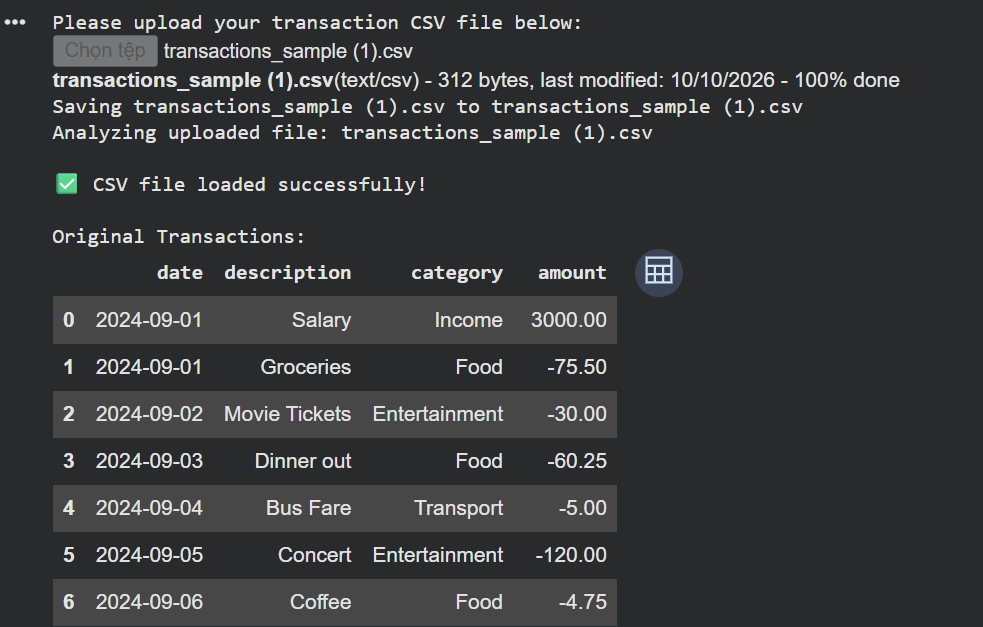

### Demonstrating Pandas for Transaction Analysis and Summary

In this section, we will show how to:
1. Load a CSV file using `pandas.read_csv` inside a `try-except` block to catch errors like a missing file.
2. Filter out income (positive values) to focus only on spending (negative values).
3. Group the transactions by category, calculate the absolute sum of spending for each category, and sort the categories from highest to lowest spending.

### Step 1: Create and Download a Sample CSV File

Run this cell to create a sample `transactions_sample.csv` file and download it to your local machine. Once downloaded, you can use it to test the uploader in the next step.

In [5]:
import pandas as pd
from google.colab import files

# Define the sample transaction data
sample_data = {
    "date": ["2024-09-01", "2024-09-01", "2024-09-02", "2024-09-03", "2024-09-04", "2024-09-05", "2024-09-06", "2024-09-07"],
    "description": ["Salary", "Groceries", "Movie Tickets", "Dinner out", "Bus Fare", "Concert", "Coffee", "Rent"],
    "category": ["Income", "Food", "Entertainment", "Food", "Transport", "Entertainment", "Food", "Housing"],
    "amount": [3000.00, -75.50, -30.00, -60.25, -5.00, -120.00, -4.75, -1000.00]
}

# Create a DataFrame and save it as a CSV
sample_df = pd.DataFrame(sample_data)
filename = "transactions_sample.csv"
sample_df.to_csv(filename, index=False)

print(f"Created '{filename}' successfully!")

# Automatically trigger a browser download for the file
files.download(filename)

Created 'transactions_sample.csv' successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
import io
from google.colab import files

def analyze_transactions(file_source):
    try:
        # Load the CSV file into a pandas DataFrame
        df = pd.read_csv(file_source)
        print("\n✅ CSV file loaded successfully!\n")

        # Display the loaded DataFrame
        print("Original Transactions:")
        display(df)

        # Filter for spending only (amount < 0)
        spending_df = df[df['amount'] < 0].copy()

        # Convert spending amounts to positive values for easier summarization
        spending_df['spending_amount'] = spending_df['amount'].abs()

        # Group by category, sum the spending, and sort from highest to lowest
        category_summary = (
            spending_df.groupby('category')['spending_amount']
            .sum()
            .reset_index()
            .sort_values(by='spending_amount', ascending=False)
        )

        print("\nTotal Spending by Category (Highest to Lowest):")
        display(category_summary)

    except FileNotFoundError:
        print("❌ Error: The specified CSV file was not found.")
    except KeyError as ke:
        print(f"❌ Error: Missing required column in the CSV file: {ke}")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")

# Prompt the user to upload a CSV file from their local computer
print("Please upload your transaction CSV file below:")
uploaded = files.upload()

# Get the first uploaded file name and run the analysis
for filename in uploaded.keys():
    print(f"Analyzing uploaded file: {filename}")
    analyze_transactions(io.BytesIO(uploaded[filename]))

Please upload your transaction CSV file below:


Saving transactions_sample (1).csv to transactions_sample (1).csv
Analyzing uploaded file: transactions_sample (1).csv

✅ CSV file loaded successfully!

Original Transactions:


,date,description,category,amount
0,2024-09-01,Salary,Income,3000.00
1,2024-09-01,Groceries,Food,-75.50
2,2024-09-02,Movie Tickets,Entertainment,-30.00
3,2024-09-03,Dinner out,Food,-60.25
4,2024-09-04,Bus Fare,Transport,-5.00
5,2024-09-05,Concert,Entertainment,-120.00
6,2024-09-06,Coffee,Food,-4.75
7,2024-09-07,Rent,Housing,-1000.00



Total Spending by Category (Highest to Lowest):


,category,spending_amount
2,Housing,1000.0
0,Entertainment,150.0
1,Food,140.5
3,Transport,5.0


#### Explanation of the Pandas & CSV implementation:

* **`pd.read_csv()`**: Reads the CSV transaction file into a structure called a DataFrame.
* **`df[df['amount'] < 0]`**: Filters the DataFrame to focus solely on transactions representing spending (negative amounts).
* **`.abs()`**: Converts negative spending values into positive ones so they are easier to aggregate and compare.
* **`groupby('category')['spending_amount'].sum()`**: Groups rows of transactions that share the same category together and sums up their spending.
* **`.sort_values(by='spending_amount', ascending=False)`**: Sorts the categories dynamically based on the total spend in descending order so the user sees their highest expenses first.
* **`try-except` structure**: Safely wraps the loading and cleaning process to alert the user clearly if they provide a file with missing columns (`KeyError`) or if the file cannot be accessed (`FileNotFoundError`).

#6: API

In my Saving Goals Coach, I want to integrate API into my app to make the user could communicate with AI and also for live exchange rate. The prompts that I asked Gemini is that "Could you demonstrate how the requests library can be used to get live exchange
rates from the free Frankfurter API and also allow user to communicate with Ai?"

With this code, what I kept is the live exchange rate of the currency when it updated the currency's fluctuation every time. Also, the structure of Gemini AI is worthy to put it in my saving goals coach, because it allows you to talk to AI. However, what I would improve for the code is allow more currency exchange for different country and not mainly focus on AUS and USA. For example, it can be Vietnam, Europe, and etc. Therefore, it would make the code more transparent and vivid. Also, for the interaction with AI coding, When I ran the Gemini code, the request failed with a 503 error because
Google's servers were experiencing high demand. Since this delay is caused by the server, if I corrected the code again, I would prefer to ask Gemini to add a retry that waits a few seconds and tries again, so the user receives an answer instead of an error. I also plan to give the AI coach custom tools, so its advice is based on the user's real goals and spending rather than general tips.

### Task 6.1: Fetching Live Exchange Rates with the Frankfurter API

We will use Python's `requests` library to connect to the free and open Frankfurter API. This allows our Savings Goal Coach to fetch live exchange rates (for example, converting AUD to USD or EUR) so that users can view their goals in different currencies.

In [ ]:
import requests

def get_exchange_rate(base_currency="AUD", target_currency="USD"):
    """
    Fetches the live exchange rate from Frankfurter API.
    """
    url = f"https://api.frankfurter.app/latest?from={base_currency}&to={target_currency}"
    try:
        response = requests.get(url)
        response.raise_for_status()  # Check for HTTP errors
        data = response.json()
        rate = data["rates"][target_currency]
        print(f"\u2705 Live Rate Fetched: 1 {base_currency} = {rate:.4f} {target_currency}")
        return rate
    except requests.exceptions.RequestException as e:
        print(f"\u274c Error fetching exchange rate: {e}")
        return None

# Test the exchange rate function
aud_to_usd_rate = get_exchange_rate("AUD", "USD")
if aud_to_usd_rate:
    goal_in_aud = 5000
    goal_in_usd = goal_in_aud * aud_to_usd_rate
    print(f"Your $5,000.00 AUD savings goal is approximately ${goal_in_usd:.2f} USD")

✅ Live Rate Fetched: 1 AUD = 0.6944 USD
Your $5,000.00 AUD savings goal is approximately $3471.75 USD


### Task 6.2: Communicating with Gemini AI

Next, we'll demonstrate how you can integrate the Gemini API into your Savings Goal Coach using the official `google-genai` SDK. This allows users to ask questions or receive personalized savings coaching.

In [ ]:
from google import genai
from google.colab import userdata

try:
    # Retrieve your API key from the Colab Secrets manager
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=GEMINI_API_KEY)

    response = client.models.generate_content(
        model='gemini-3.8-flash',
        contents='Give me three quick tips to save money on a university student budget.',
    )
    print("\n🤖 Gemini Financial Coach Advice:")
    print(response.text)
except Exception as e:
    print(f"\u274c AI Integration Error: {e}")
    print("Please ensure you have configured your GEMINI_API_KEY in the secrets tab (key icon) on the left panel.")


🤖 Gemini Financial Coach Advice:
Here are three high-impact, easy-to-implement tips:

1. **Never buy brand-new textbooks right away:** Wait until the first week of class to see if the book is actually required. When it is, check your university library first, look into renting digital copies, buy used editions, or search for free open-source PDFs before paying retail price.
2. **Cut out the "convenience food" tax:** Food delivery apps (DoorDash, Uber Eats) and daily $6 coffees are the fastest ways to drain a student bank account. Invest in a travel mug, make coffee at home, and batch-cook simple meals (like pasta bakes, chili, or stir-fries) to take to campus.
3. **Exploit your student ID everywhere:** Always ask if a business offers a student discount—from clothing stores and public transit to streaming services (Spotify, Prime) and software (free Microsoft Office/Adobe perks). Also, take full advantage of free campus amenities like the campus gym, health clinic, and events that offe

#7: Gradio for your interface

For my saving goal coach, I want to explore how Gradio can be used to build a simple web interface so users can add goals, upload their
transactions and chat with the coach without needing to read or run any code. What I asked Gemnini is that I told it to demonstrate how Gradio can be used to build a simple interface with tabs: one tab where the user enters a savings goal (name, target amount, amount
already saved and months) and sees how much to save each month, and one tab where the user uploads a CSV of transactions and sees total spending by category.

With the result below, it met all of my requirement because the user can see how much money would they save in a month and the AI can analyze their spending with the transaction file. However, what I rejected or corrected is that when I uploaded a CSV file that did not contain the required category and amount columns, the app displayed only "Error" instead of a helpful message. Thus, it might make the user confuse what is the mistake. To correced this,I asked Gemini to added a separate gr.Markdown component for messages and changed the function to return both a message and a table. When I uploaded the same file again, the app displayed "The CSV is missing the 'category' column", so the user now knows exactly what to fix in their file.

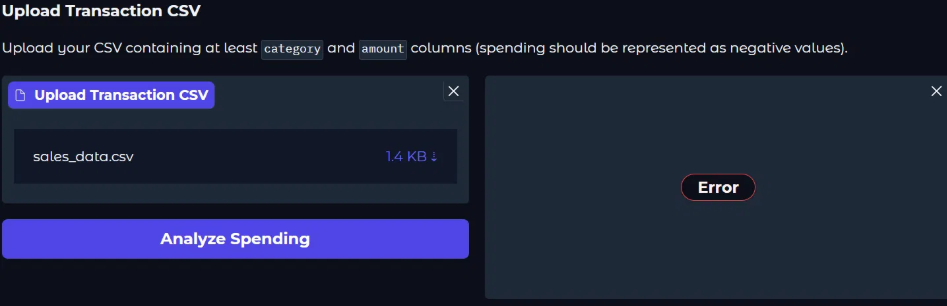

In [3]:
!pip install -q gradio

Now, we will define the core helper functions and assemble a two-tab interface using Gradio's `Blocks` layout.

In [4]:
import gradio as gr
import pandas as pd
import io

def calculate_savings_interface(goal_name, target_amount, current_savings, months_remaining):
    try:
        target = float(target_amount)
        current = float(current_savings)
        months = int(months_remaining)

        if target <= 0 or months <= 0:
            return "❌ Target amount and months remaining must be positive numbers greater than zero."

        needed = target - current
        if needed <= 0:
            return f"🎉 Congratulations! You have already met your goal for '{goal_name}'!"

        monthly_needed = needed / months
        return (
            f"📊 **Goal Progress Summary for '{goal_name}':**\n\n"
            f"- Total Remaining Needed: ${needed:,.2f}\n"
            f"- Time Frame: {months} months\n"
            f"- **Required Monthly Savings: ${monthly_needed:,.2f} / month**"
        )
    except ValueError:
        return "❌ Invalid inputs. Please ensure target amount, current savings, and months are valid numbers."

def analyze_uploaded_csv(file_obj):
    # Return signature: (status_message, dataframe)
    if file_obj is None:
        return "⚠️ Please upload a valid CSV file.", pd.DataFrame()
    try:
        # Read the uploaded file
        df = pd.read_csv(file_obj.name)

        # Validate required columns individually for explicit errors
        required_columns = ['category', 'amount']
        for col in required_columns:
            if col not in df.columns:
                return f"❌ The CSV is missing the required **'{col}'** column. Please check your file structure.", pd.DataFrame()

        # Filter for spending only (amount < 0)
        spending_df = df[df['amount'] < 0].copy()
        if spending_df.empty:
            return "ℹ️ No spending transactions (negative amounts) were found in this file.", pd.DataFrame()

        spending_df['spending_amount'] = spending_df['amount'].abs()

        # Group, sum, and sort
        summary = (
            spending_df.groupby('category')['spending_amount']
            .sum()
            .reset_index()
            .sort_values(by='spending_amount', ascending=False)
        )

        # Formatting for display
        summary.rename(columns={'category': 'Category', 'spending_amount': 'Total Spending ($)'}, inplace=True)
        return "✅ Analysis completed successfully! See your spending summary below.", summary
    except Exception as e:
        return f"❌ Error processing file: {e}", pd.DataFrame()

# --- Build the Gradio App with Tabs ---
with gr.Blocks() as demo:
    gr.Markdown("# 🎯 Savings Goal Coach & Finance Assistant")
    gr.Markdown("Welcome to your personal finance helper! Use the tabs below to manage your goals and analyze your spending.")

    with gr.Tab("Savings Goal Coach"):
        gr.Markdown("### Calculate Your Savings Milestones")
        with gr.Row():
            with gr.Column():
                goal_name = gr.Textbox(label="Goal Name", placeholder="e.g., Japan Trip, Emergency Fund")
                target_amount = gr.Number(label="Target Amount ($)", value=1000)
                current_savings = gr.Number(label="Current Savings ($)", value=0)
                months_remaining = gr.Number(label="Months Remaining", value=12, precision=0)
                calculate_btn = gr.Button("Calculate Monthly Goal", variant="primary")
            with gr.Column():
                result_output = gr.Markdown(label="Calculation Result")

        calculate_btn.click(
            fn=calculate_savings_interface,
            inputs=[goal_name, target_amount, current_savings, months_remaining],
            outputs=result_output
        )

    with gr.Tab("Transaction Analyzer"):
        gr.Markdown("### Upload Transaction CSV")
        gr.Markdown("Upload your CSV containing at least `category` and `amount` columns (spending should be represented as negative values).")
        with gr.Row():
            with gr.Column():
                file_input = gr.File(label="Upload Transaction CSV", file_types=[".csv"])
                analyze_btn = gr.Button("Analyze Spending", variant="primary")
            with gr.Column():
                status_output = gr.Markdown(value="Upload a file and press Analyze to start.")
                analysis_output = gr.Dataframe(label="Total Spending by Category")

        analyze_btn.click(
            fn=analyze_uploaded_csv,
            inputs=file_input,
            outputs=[status_output, analysis_output]
        )

# Launch the app with sharing enabled
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffb5fa566307700a62.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
